# Daily and monthly statistics

The `earthkit.transforms.temporal` module provides a high-level API for computing daily and monthly statistics from time series data. Instead of manually grouping by day or month and applying reductions, you can call convenience functions such as `daily_mean`, `daily_max`, `daily_min`, `daily_std`, `daily_sum`, and their monthly equivalents (`monthly_mean`, `monthly_max`, etc.).

These functions automatically detect the time dimension in your data and handle the grouping for you. They accept any data format understood by `earthkit.data` (e.g. GRIB, NetCDF) as well as `xarray.Dataset` and `xarray.DataArray` objects directly.

In [1]:
from earthkit import data as ekd
from earthkit import plots as ekp
from earthkit import transforms as ekt

## Load some test data

Load some sample point data from a remote netcdf file.

In [2]:
# Get some demonstration ERA5 data, this could be any url or path to an ERA5 grib or netCDF file.
era5_reading_1940_2025_point_data = ekd.from_source("url", "https://sites.ecmwf.int/repository/earthkit-data/test-data/ERA5-Reading-2m-temperature-1940-2025.nc")
era5_reading_1940_2025_point_data

path,/var/folders/l2/529q7bzs665bnrn7_wjx1nsr0000gn/T/earthkit-data-edwardcomyn-platt/url-026ad38a941e4653283b7732cbbdeebe3b2e03395d9ac98a5f4d28d925354841.nc
size,8.6 MiB
types,"xarray, pandas, fieldlist, numpy, array"


## Calculate the daily statistics

Below we demonstrate the flexibility of the transforms functions by passing in
the raw file object, an `xarray.Dataset` and a `pandas.DataFrame`.
The functions can handle all types.

In [3]:
era5_reading_xr = era5_reading_1940_2025_point_data.to_xarray()
era5_reading_pd = era5_reading_xr.to_dataframe()

# Compute with file object input
era5_daily_mean = ekt.temporal.daily_mean(era5_reading_1940_2025_point_data)

# Compute with xarray input
era5_daily_max = ekt.temporal.daily_max(era5_reading_xr)

# Compute with pandas input
era5_daily_min = ekt.temporal.daily_min(era5_reading_pd)
# Pandas does not preserve attributes, so we manually set the units for plotting purposes
era5_daily_min.t2m.attrs.update({"units": "kelvin"})

era5_daily_mean

<xarray.Dataset> Size: 377kB
Dimensions:     (valid_time: 31412)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 251kB 1940-01-01 ... 2025-12-31
    latitude    float64 8B 51.5
    longitude   float64 8B -1.0
Data variables:
    t2m         (valid_time) float32 126kB 272.6 271.0 271.5 ... 276.6 273.0
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Calculate the monthly statistics

There are similar functions for monthly aggregations, and for both daily and monthly there are
generic `daily_reduce` and `monthly_reduce` functions which take a how argument, as
demonstrated in the previous notebook.

In [4]:
era5_monthly_mean = ekt.temporal.monthly_mean(era5_reading_xr)
era5_monthly_std = ekt.temporal.monthly_reduce(era5_reading_xr, how="std")
era5_monthly_std

<xarray.Dataset> Size: 12kB
Dimensions:     (valid_time: 1032)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-12-01
    latitude    float64 8B 51.5
    longitude   float64 8B -1.0
Data variables:
    t2m         (valid_time) float32 4kB 4.108 4.676 3.86 ... 2.682 4.679 3.395
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Rolling reductions

It is also possible to calculate rolling reductions with a simplified API.
Pease note that improved API to the rolling_reduce method is an ongoing task, feedback welcome on this.

In [10]:
era5_rolling = ekt.temporal.rolling_reduce(
    era5_reading_xr,
    24*30,
    how_reduce="mean",
    center=True,
)
era5_rolling

<xarray.Dataset> Size: 9MB
Dimensions:     (valid_time: 753888)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:...
    latitude    float64 8B 51.5
    longitude   float64 8B -1.0
Data variables:
    t2m         (valid_time) float32 3MB dask.array<chunksize=(753887,), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Plot a time-series for all our data

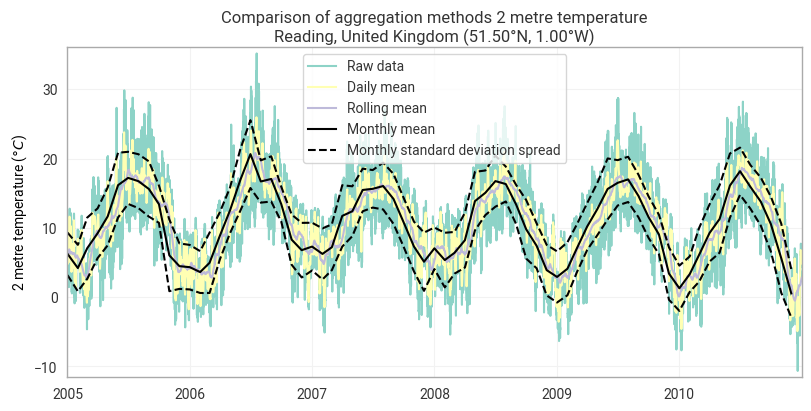

In [11]:
time_window = slice("2005", "2010")
chart = ekp.TimeSeries()

# Plot the raw data and various aggregations on the same chart for comparison:
# Raw data:
chart.line(era5_reading_xr.sel(valid_time=time_window), units="celsius", label="Raw data")
# Daily mean:
chart.line(era5_daily_mean.sel(valid_time=time_window), units="celsius", label="Daily mean")
# Rolling mean:
chart.line(era5_rolling.sel(valid_time=time_window), units="celsius", label="Rolling mean")

# Add the monthly mean as a black solid line and spread as black dotted lines:
chart.line(era5_monthly_mean.sel(valid_time=time_window), units="celsius", label="Monthly mean", color="black")
upper_m = era5_monthly_mean + era5_monthly_std
lower_m = era5_monthly_mean - era5_monthly_std
chart.line(
    upper_m.sel(valid_time=time_window),
    units="celsius",
    label="Monthly standard deviation spread",
    linestyle="--",
    color="black",
)
chart.line(lower_m.sel(valid_time=time_window), units="celsius", linestyle="--", color="black")

chart.title(
    "Comparison of aggregation methods {variable_name}\n{location:%c}, {location:%C} ({latitude:%Lt}, {longitude:%Ln})"
)

chart.ylabel()

chart.legend()

chart.show()